In [1]:


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances



In [2]:
def kmeans(X,k,max_iterations=1000):
    from sklearn.metrics import pairwise_distances
    # initialize iteration counter
    it = 0
    repeat = True
    
    # number of datapoints
    m = X.shape[0] 
    
    # initialization
    means = X[np.random.choice(m,k,replace=False)] 
    dist = pairwise_distances(X,means)
    clusters = np.argmin(dist, axis=1)
 
    
    while repeat and it<max_iterations:
        
        # update means; # if a cluster has no data points associated with it, replace it with a random data point
        means = np.array([np.mean(X[clusters==i], axis=0) 
                          if np.sum(clusters==i)!=0
                          else  X[np.random.randint(m)]
                          for i in range(k)])
        
        # update clusters
        dist = pairwise_distances(X,means)
        new_clusters = np.argmin(dist, axis=1)
        
        # check if the new clusters are equal to the previous clusters
        if np.sum(clusters!=new_clusters)==0: 
            repeat = False
        clusters = new_clusters
                
        it += 1 # increment iteration counter by 1
    
    return clusters, means

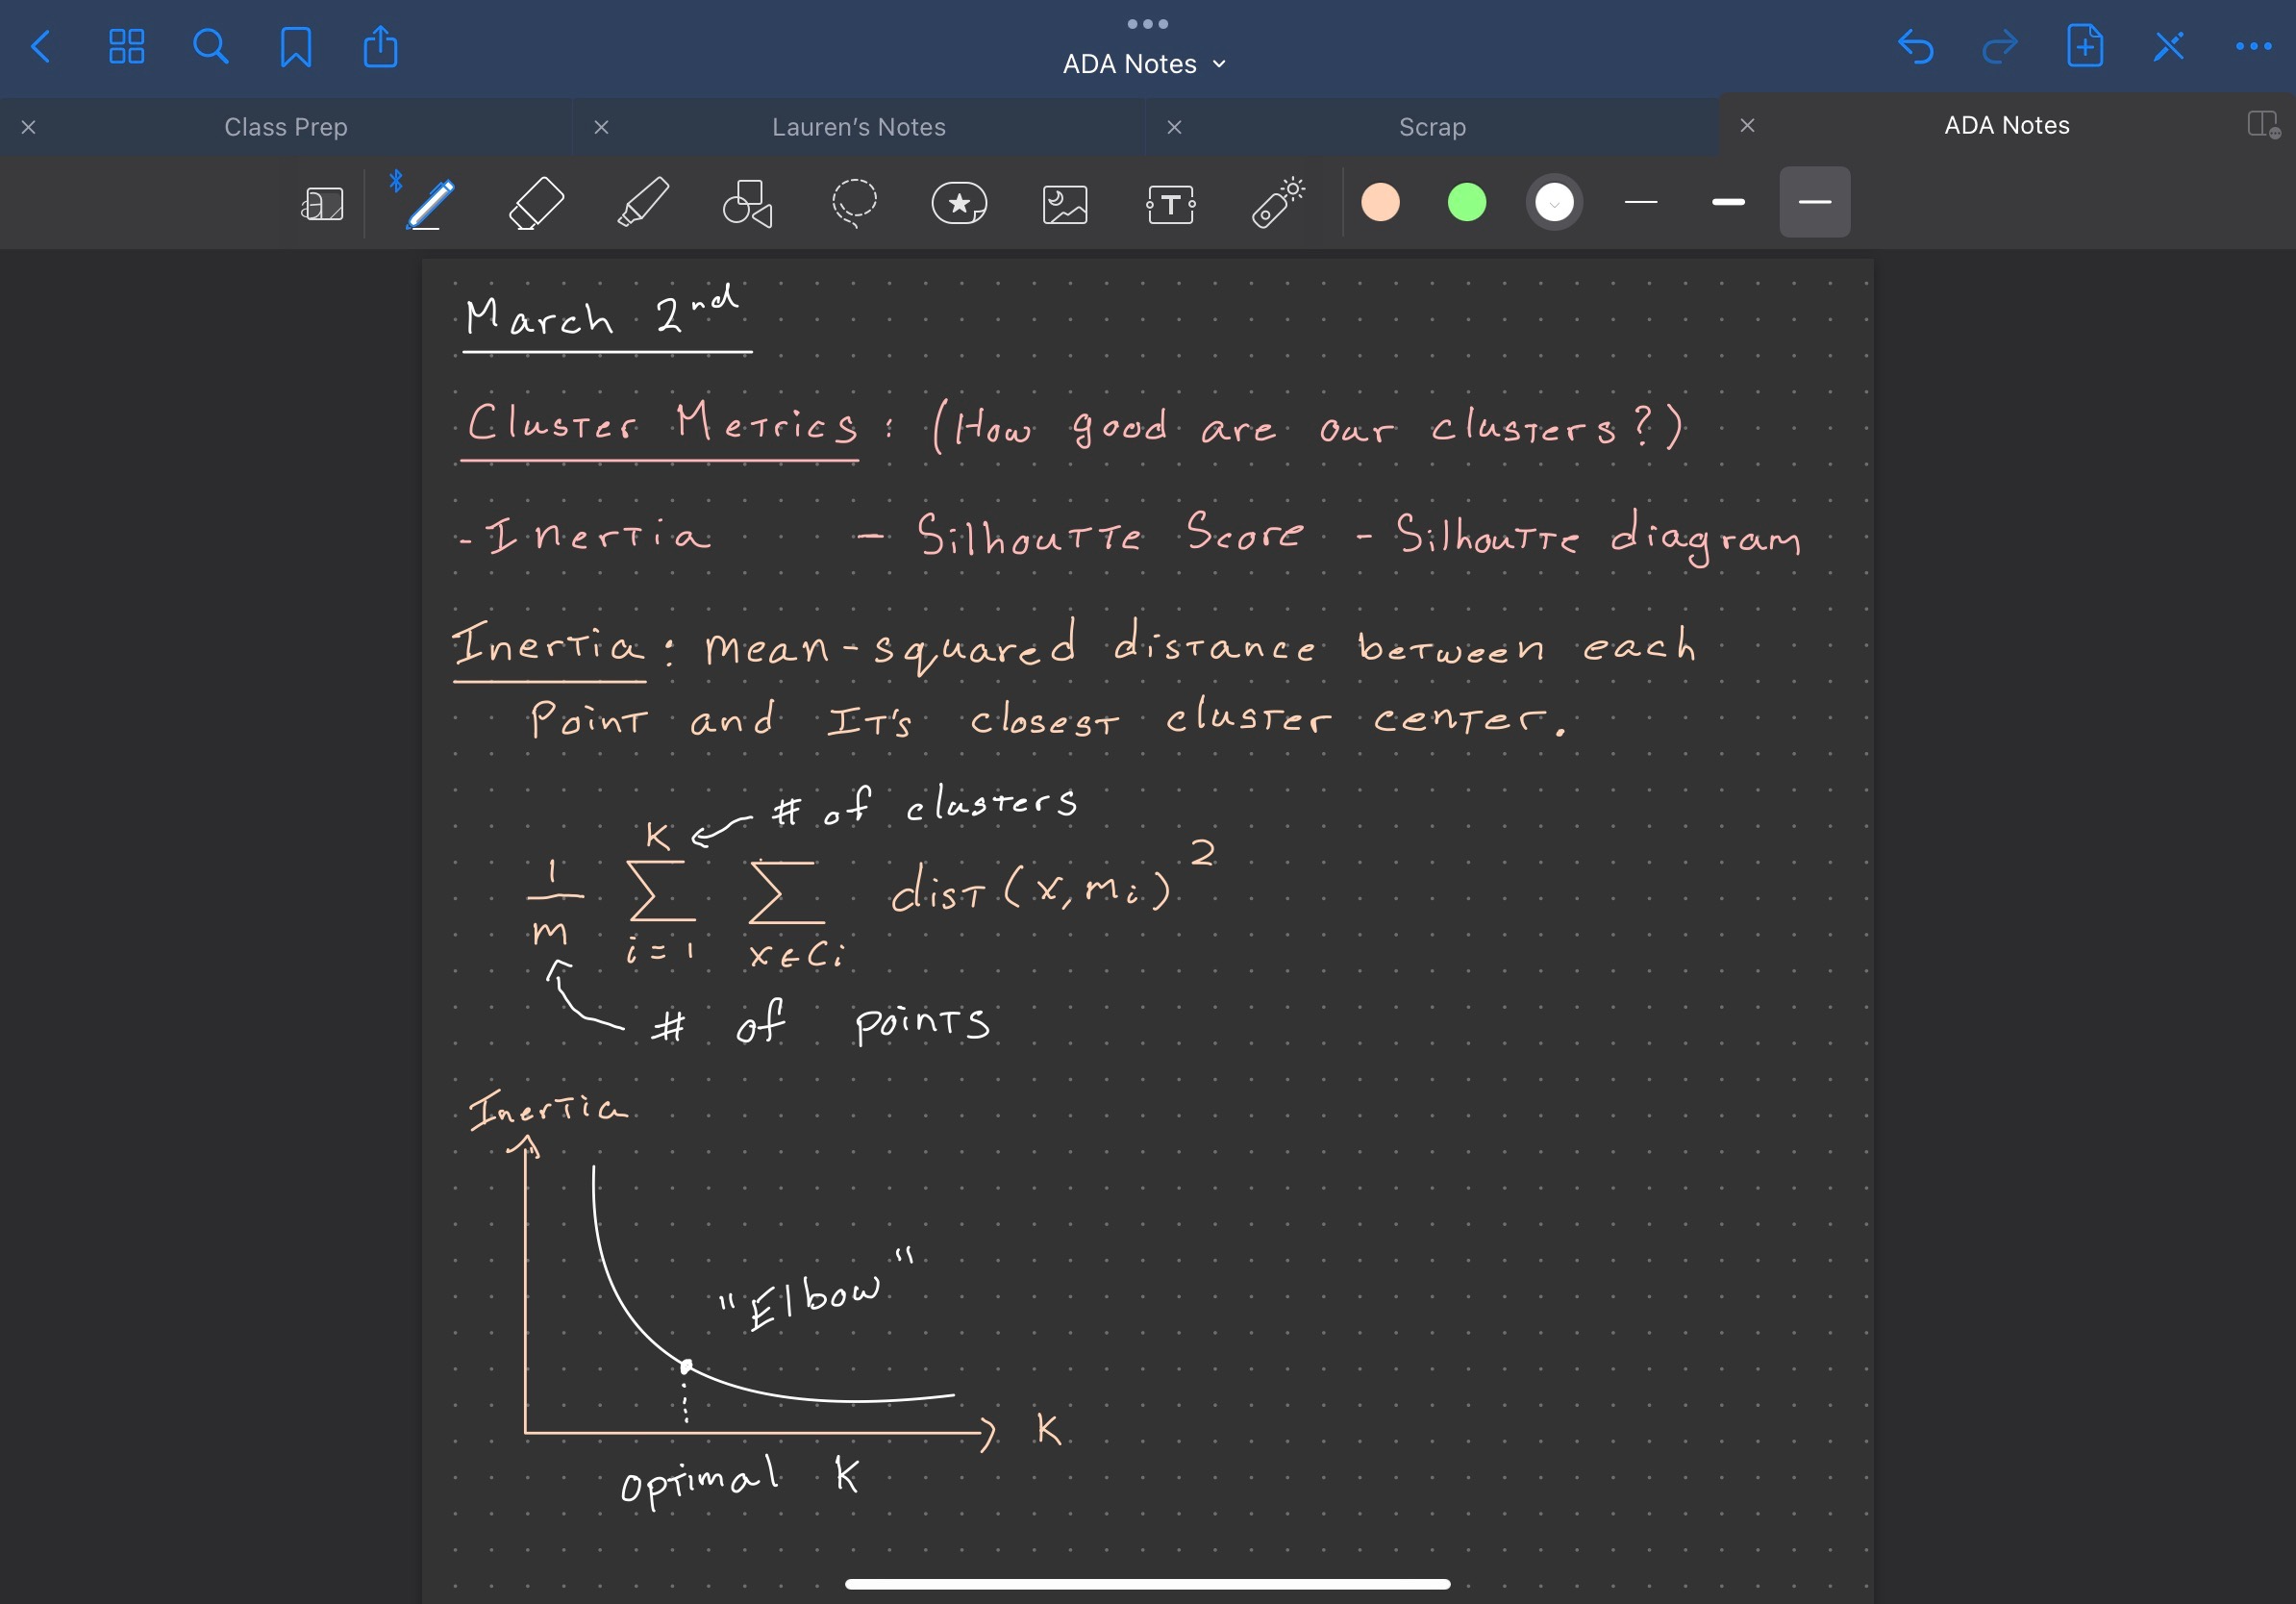

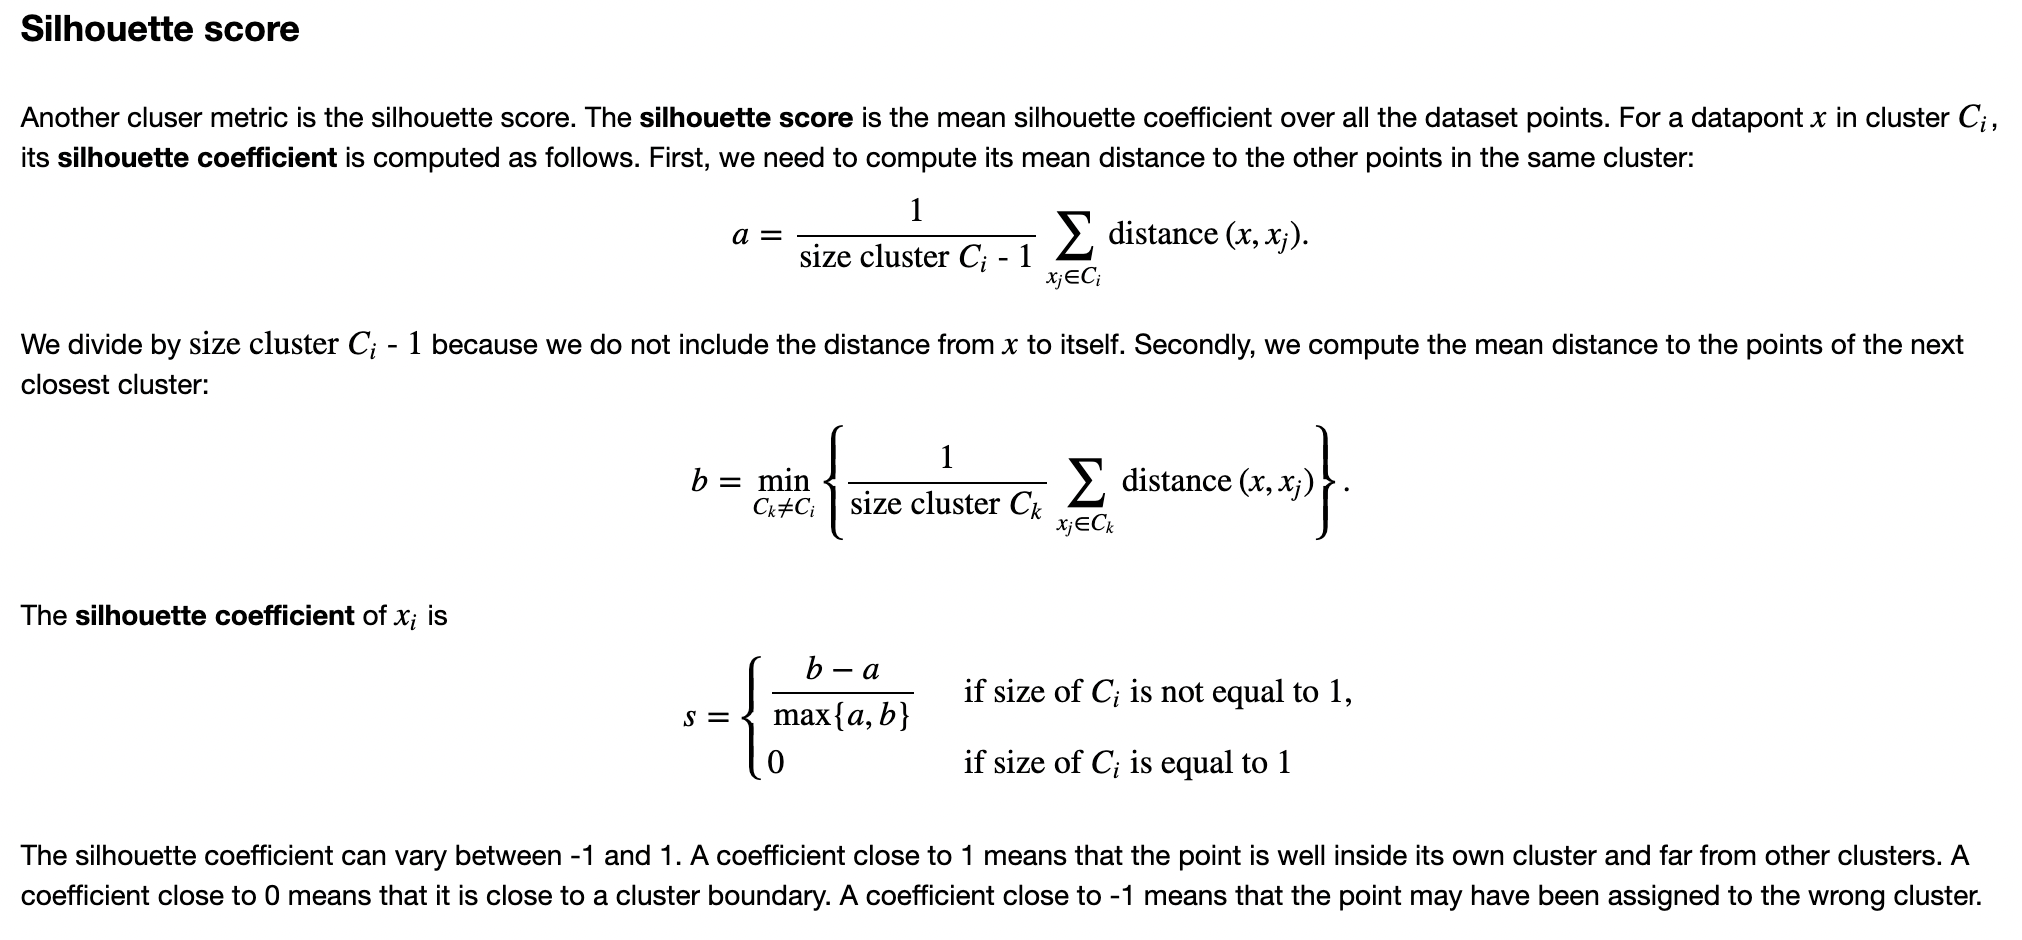

#### Silhouette Diagram

A plot of all silhouette coeffs (sorted by cluster)

****
## Inertia

In [4]:
def inertia(X,clusters,means):

    m = len(clusters)
    k = len(means)

    t = np.sum([
                np.sum((X[clusters==i]-means[i])**2)
                for i in range(k)
                ])/m
    return t

In [8]:
# using intertia to choose k (the number of clusters)

k_min = 1
k_max = 20

inertias = np.zeros(k_max - k_min)
for i,k in enumerate(range(k_min,k_max)):
    clusters, means = kmeans(X,k)
    inertias[i] = inertia(X,clusters,means)
plt.plot(range(k_min,k_max),inertias,'--o')
plt.xlabel('number of clusters')
plt.ylabel('inertia')



NameError: name 'X' is not defined

## Silhouette score

In [9]:
# distance matrix
dist = pairwise_distances(X)

NameError: name 'X' is not defined

In [ ]:
clusters, means = kmeans(X,k=4)

In [ ]:
# cluster sizes
sizes = np.bincount(clusters)
sizes

In [14]:
# mean intra cluster distance
m = 2
a = [ np.sum(dist[clusters ==clusters[i],i])/(sizes[clusters[i]]-1) 
                                              if sizes[clusters[i]]!=1 else 0 for i in range(m) ]

NameError: name 'sizes' is not defined

In [18]:
# mean nearest-cluster distance

b = [
    np.min([np.mean(dist[clusters==j,i])
                    for j in range(k)
                    if j!=i])
    for i in range(m)
]

ValueError: zero-size array to reduction operation minimum which has no identity